# Within-Condition Baseline Training — Results

This notebook presents the authoritative v2 within-condition baseline training results. Seven classifiers are evaluated on binary disease-vs-control classification for each of the three neurological conditions (PD, HD, ALS) using subject-level leave-one-subject-out cross-validation (LOSO-CV) with nested hyperparameter tuning.

**Data source:** `experiments/results/v2/{pd,hd,als}_results_v2.json`  
**Training scripts:** `scripts/training/run_within_condition_local.py` and `scripts/training/run_within_condition_modal.py`  
**Figure output:** `report/figures/v2/pdf/` and `report/figures/v2/png/`

Each classifier is evaluated with an aggregate F1 macro score computed over the full concatenated out-of-fold prediction vector. Per-fold F1 is undefined because each outer fold holds out exactly one subject, who belongs to exactly one class.

Each visualisation cell appears twice conceptually: once as notebook output for inspection and once as a saved figure for the paper.


In [39]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import polars as pl
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display

from features import ALL_FEATURE_COLS

matplotlib.rcParams.update({
    'font.size': 9,
    'font.family': 'serif',
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

RESULTS_DIR = Path('../experiments/results/v2')
PROCESSED = Path('../data/processed')
FIGURES_PDF = Path('../report/figures/v2/pdf')
FIGURES_PNG = Path('../report/figures/v2/png')
FIGURES_PDF.mkdir(parents=True, exist_ok=True)
FIGURES_PNG.mkdir(parents=True, exist_ok=True)

CONDITIONS = ['pd', 'hd', 'als']
CLF_NAMES = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABELS = ['RF', 'KNN', 'SVM', 'DT', 'QDA', 'XGBoost', 'LightGBM']
COND_LABELS = {'pd': 'PD', 'hd': 'HD', 'als': 'ALS'}


In [40]:
# Load authoritative v2 results, build summary tables, and extract stored predictions.
results = {}
for cond in CONDITIONS:
    with open(RESULTS_DIR / f'{cond}_results_v2.json') as f:
        results[cond] = json.load(f)

BEST_CLF = {
    cond: max(CLF_NAMES, key=lambda clf: results[cond]['classifiers'][clf]['f1_macro'])
    for cond in CONDITIONS
}
BEST_CLF_LABEL = {
    cond: CLF_LABELS[CLF_NAMES.index(BEST_CLF[cond])]
    for cond in CONDITIONS
}
BEST_F1 = {
    cond: results[cond]['classifiers'][BEST_CLF[cond]]['f1_macro']
    for cond in CONDITIONS
}

# F1 macro table: rows = classifiers, columns = conditions
f1_rows = []
for clf_name, clf_label in zip(CLF_NAMES, CLF_LABELS):
    row = {'Classifier': clf_label}
    for cond in CONDITIONS:
        row[COND_LABELS[cond]] = results[cond]['classifiers'][clf_name]['f1_macro']
    f1_rows.append(row)

f1_df = pl.DataFrame(f1_rows)

# Modal params table: rows = (condition, classifier)
modal_rows = []
for cond in CONDITIONS:
    n_folds = results[cond]['pool_subjects']
    for clf_name, clf_label in zip(CLF_NAMES, CLF_LABELS):
        clf_res = results[cond]['classifiers'][clf_name]
        params_str = ', '.join(
            f"{k.replace('clf__', '')}={v}"
            for k, v in clf_res['modal_params'].items()
        )
        modal_rows.append({
            'Condition': COND_LABELS[cond],
            'Classifier': clf_label,
            'Modal Params': params_str,
            'Frequency': f"{clf_res['modal_frequency']}/{n_folds}",
        })

modal_df = pl.DataFrame(modal_rows)

ablation_rows = []
summary_rows = []
for cond in CONDITIONS:
    smote_count = 0
    no_smote_count = 0
    for clf_name, clf_label in zip(CLF_NAMES, CLF_LABELS):
        clf_res = results[cond]['classifiers'][clf_name]
        selected = clf_res.get('selected_resampling', 'not_recorded')
        if selected == 'smote':
            smote_count += 1
        elif selected == 'no_smote':
            no_smote_count += 1
        ablation_rows.append({
            'Condition': COND_LABELS[cond],
            'condition_key': cond,
            'Classifier': clf_label,
            'classifier_key': clf_name,
            'SMOTE': clf_res.get('f1_macro_smote', clf_res['f1_macro']),
            'No SMOTE': clf_res.get('f1_macro_no_smote', clf_res['f1_macro']),
            'Selected': selected,
        })
    summary_rows.append({
        'Condition': COND_LABELS[cond],
        'condition_key': cond,
        'Best classifier': BEST_CLF_LABEL[cond],
        'Best F1': BEST_F1[cond],
        'SMOTE winners': smote_count,
        'No-SMOTE winners': no_smote_count,
        'Pool subjects': results[cond]['pool_subjects'],
        'Pool strides': results[cond]['pool_strides'],
    })

ablation_df = pl.DataFrame(ablation_rows)
resampling_summary_df = pl.DataFrame(summary_rows)

# Stored predictions from the authoritative nested LOSO-CV run.
y_true_pd = np.array(results['pd']['classifiers'][BEST_CLF['pd']]['y_true'])
y_pred_pd = np.array(results['pd']['classifiers'][BEST_CLF['pd']]['y_pred'])
y_true_hd = np.array(results['hd']['classifiers'][BEST_CLF['hd']]['y_true'])
y_pred_hd = np.array(results['hd']['classifiers'][BEST_CLF['hd']]['y_pred'])
y_true_als = np.array(results['als']['classifiers'][BEST_CLF['als']]['y_true'])
y_pred_als = np.array(results['als']['classifiers'][BEST_CLF['als']]['y_pred'])

assert abs(f1_score(y_true_pd, y_pred_pd, average='macro') - BEST_F1['pd']) < 1e-6
assert abs(f1_score(y_true_hd, y_pred_hd, average='macro') - BEST_F1['hd']) < 1e-6
assert abs(f1_score(y_true_als, y_pred_als, average='macro') - BEST_F1['als']) < 1e-6

print('Pool statistics:')
for cond in CONDITIONS:
    r = results[cond]
    print(f"  {COND_LABELS[cond]}: {r['pool_subjects']} subjects, {r['pool_strides']:,} strides")
print()
print('Best classifier per condition:')
for cond in CONDITIONS:
    print(f"  {COND_LABELS[cond]}: {BEST_CLF_LABEL[cond]} (F1={BEST_F1[cond]:.4f})")
print()
print(f1_df)


Pool statistics:
  PD: 23 subjects, 5,738 strides
  HD: 27 subjects, 6,661 strides
  ALS: 21 subjects, 4,467 strides

Best classifier per condition:
  PD: DT (F1=0.8668)
  HD: XGBoost (F1=0.9562)
  ALS: KNN (F1=0.8300)

shape: (7, 4)
┌────────────┬──────────┬──────────┬──────────┐
│ Classifier ┆ PD       ┆ HD       ┆ ALS      │
│ ---        ┆ ---      ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╪══════════╡
│ RF         ┆ 0.772966 ┆ 0.953043 ┆ 0.740073 │
│ KNN        ┆ 0.758351 ┆ 0.804574 ┆ 0.829963 │
│ SVM        ┆ 0.735295 ┆ 0.87199  ┆ 0.709767 │
│ DT         ┆ 0.866848 ┆ 0.90527  ┆ 0.690098 │
│ QDA        ┆ 0.739148 ┆ 0.764766 ┆ 0.820878 │
│ XGBoost    ┆ 0.735052 ┆ 0.956214 ┆ 0.714802 │
│ LightGBM   ┆ 0.81861  ┆ 0.862585 ┆ 0.751959 │
└────────────┴──────────┴──────────┴──────────┘


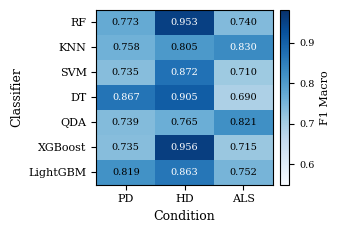

Saved: f1_within_condition_heatmap.pdf / .png


In [41]:
# Build F1 value matrix for plotting.
f1_values = np.array([
    [results[cond]['classifiers'][clf]['f1_macro'] for cond in CONDITIONS]
    for clf in CLF_NAMES
])

fig, ax = plt.subplots(figsize=(3.5, 2.4))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0.55, vmax=0.98)

im = ax.imshow(f1_values, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_xlabel('Condition')
ax.set_ylabel('Classifier')

for i in range(len(CLF_NAMES)):
    for j in range(len(CONDITIONS)):
        v = f1_values[i, j]
        text_color = 'white' if norm(v) > 0.65 else 'black'
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=7, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('F1 Macro', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'f1_within_condition_heatmap.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'f1_within_condition_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: f1_within_condition_heatmap.pdf / .png')


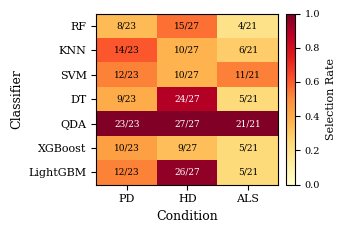

Saved: modal_frequency_heatmap.pdf / .png


In [42]:
# Modal hyperparameter stability — normalised selection rate heatmap for paper
freq_values = np.array([
    [
        results[cond]['classifiers'][clf]['modal_frequency'] / results[cond]['pool_subjects']
        for cond in CONDITIONS
    ]
    for clf in CLF_NAMES
])

fig, ax = plt.subplots(figsize=(3.5, 2.4))

cmap_freq = plt.cm.YlOrRd
norm_freq = mcolors.Normalize(vmin=0.0, vmax=1.0)

im = ax.imshow(freq_values, cmap=cmap_freq, norm=norm_freq, aspect='auto')

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_xlabel('Condition')
ax.set_ylabel('Classifier')

for i in range(len(CLF_NAMES)):
    for j in range(len(CONDITIONS)):
        v = freq_values[i, j]
        freq = results[CONDITIONS[j]]['classifiers'][CLF_NAMES[i]]['modal_frequency']
        n = results[CONDITIONS[j]]['pool_subjects']
        text_color = 'white' if norm_freq(v) > 0.65 else 'black'
        ax.text(j, i, f'{freq}/{n}', ha='center', va='center', fontsize=6.5, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Selection Rate', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'modal_frequency_heatmap.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'modal_frequency_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: modal_frequency_heatmap.pdf / .png')


### Resampling Ablation by Classifier

This figure summarises the authoritative Step 2 SMOTE ablation directly from the stored v2 result JSONs. Each panel shows the paired `SMOTE` and `No SMOTE` F1 values for one condition, with the selected arm highlighted in the bar annotation.


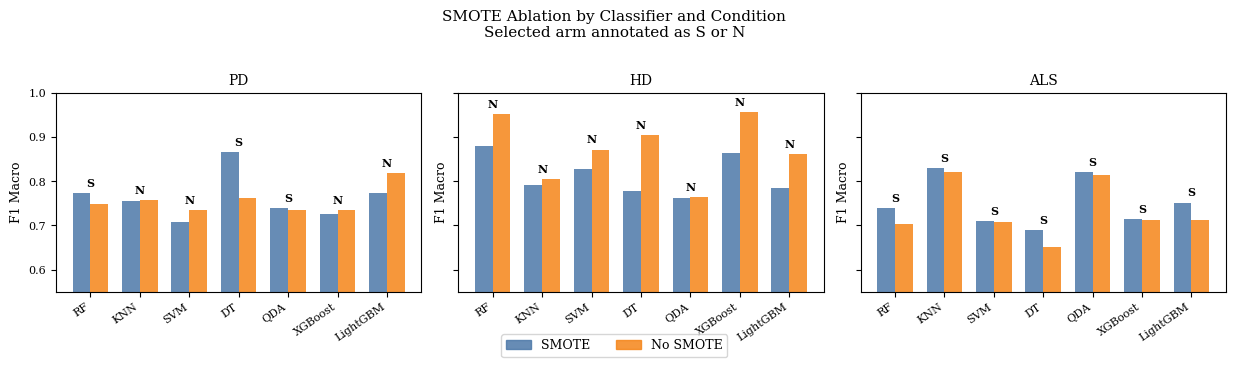

Saved: smote_ablation_by_classifier.pdf / .png


In [43]:
cond_order = ['pd', 'hd', 'als']
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=True)
axes = np.atleast_1d(axes)

for ax, cond in zip(axes, cond_order):
    sub = ablation_df.filter(pl.col('condition_key') == cond)
    smote_vals = sub['SMOTE'].to_numpy()
    no_smote_vals = sub['No SMOTE'].to_numpy()
    selected = sub['Selected'].to_list()

    x = np.arange(len(CLF_LABELS))
    width = 0.36
    ax.bar(x - width/2, smote_vals, width, color='#4C78A8', alpha=0.85, label='SMOTE')
    ax.bar(x + width/2, no_smote_vals, width, color='#F58518', alpha=0.85, label='No SMOTE')

    for idx, choice in enumerate(selected):
        y = max(smote_vals[idx], no_smote_vals[idx]) + 0.01
        ax.text(idx, y, 'S' if choice == 'smote' else 'N', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(COND_LABELS[cond], fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_LABELS, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0.55, 1.0)
    ax.set_ylabel('F1 Macro')
    ax.axhline(0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

handles = [
    plt.Rectangle((0, 0), 1, 1, color='#4C78A8', alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color='#F58518', alpha=0.85),
]
fig.legend(handles, ['SMOTE', 'No SMOTE'], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle('SMOTE Ablation by Classifier and Condition\nSelected arm annotated as S or N', fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'smote_ablation_by_classifier.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'smote_ablation_by_classifier.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: smote_ablation_by_classifier.pdf / .png')


### Exact SMOTE vs No-SMOTE Values

The bar chart above is useful for visual comparison, but this table gives the exact authoritative Step 2 ablation values for every classifier-condition pair. The numeric columns now use a consistent heatmap scheme: **blue** for `SMOTE`, **orange** for `No SMOTE`, and the `Selected` columns use matching categorical tints so the winning arm is easy to read at a glance.


/tmp/ipykernel_127979/4213368124.py:46: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_ablation_table = styled_ablation_table.applymap(categorical_selected_style, subset=selected_cols)


,Classifier,PD SMOTE,PD No SMOTE,PD Selected,HD SMOTE,HD No SMOTE,HD Selected,ALS SMOTE,ALS No SMOTE,ALS Selected
0,RF,0.7730,0.7497,SMOTE,0.8795,0.9530,No SMOTE,0.7401,0.7041,SMOTE
1,KNN,0.7552,0.7584,No SMOTE,0.7919,0.8046,No SMOTE,0.8300,0.8220,SMOTE
2,SVM,0.7087,0.7353,No SMOTE,0.8268,0.8720,No SMOTE,0.7098,0.7078,SMOTE
3,DT,0.8668,0.7616,SMOTE,0.7781,0.9053,No SMOTE,0.6901,0.6517,SMOTE
4,QDA,0.7391,0.7352,SMOTE,0.7611,0.7648,No SMOTE,0.8209,0.8137,SMOTE
5,XGBoost,0.7266,0.7351,No SMOTE,0.8639,0.9562,No SMOTE,0.7148,0.7131,SMOTE
6,LightGBM,0.7730,0.8186,No SMOTE,0.7838,0.8626,No SMOTE,0.7520,0.7119,SMOTE


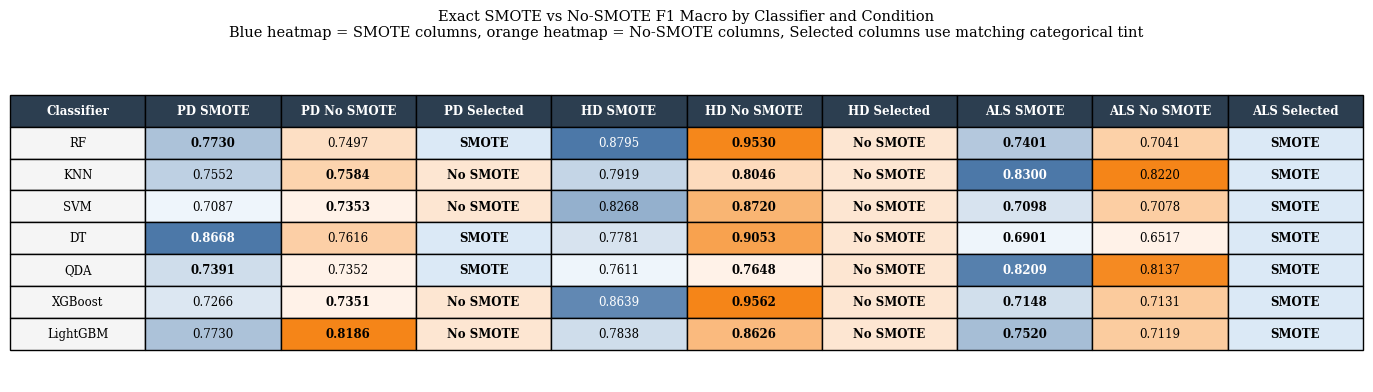

Saved: smote_ablation_table.pdf / .png


In [44]:
ablation_table_rows = []
for clf_name, clf_label in zip(CLF_NAMES, CLF_LABELS):
    row = {'Classifier': clf_label}
    for cond in CONDITIONS:
        entry = ablation_df.filter(
            (pl.col('condition_key') == cond) &
            (pl.col('classifier_key') == clf_name)
        ).to_dicts()[0]
        row[f'{COND_LABELS[cond]} SMOTE'] = float(entry['SMOTE'])
        row[f'{COND_LABELS[cond]} No SMOTE'] = float(entry['No SMOTE'])
        row[f'{COND_LABELS[cond]} Selected'] = 'SMOTE' if entry['Selected'] == 'smote' else 'No SMOTE'
    ablation_table_rows.append(row)

ablation_table_df = pl.DataFrame(ablation_table_rows)
ablation_table_pd = ablation_table_df.to_pandas()

col_labels = list(ablation_table_pd.columns)
smote_cols = [c for c in col_labels if c.endswith(' SMOTE') and 'No SMOTE' not in c]
no_smote_cols = [c for c in col_labels if c.endswith('No SMOTE')]
selected_cols = [c for c in col_labels if c.endswith('Selected')]

smote_cmap = mcolors.LinearSegmentedColormap.from_list(
    'smote_cmap', ['#eef5fb', '#4C78A8']
)
no_smote_cmap = mcolors.LinearSegmentedColormap.from_list(
    'no_smote_cmap', ['#fff2e8', '#F58518']
)

def categorical_selected_style(val):
    if val == 'SMOTE':
        return 'background-color: #dbe9f6; color: #1f4e79; font-weight: bold'
    return 'background-color: #fde6d2; color: #a64b00; font-weight: bold'

styled_ablation_table = (
    ablation_table_pd.style
    .format({col: '{:.4f}' for col in smote_cols + no_smote_cols})
    .set_caption(
        'Exact SMOTE vs No-SMOTE F1 Macro by Classifier and Condition '
        '(blue = SMOTE heatmap, orange = No-SMOTE heatmap)'
    )
)
for col in smote_cols:
    styled_ablation_table = styled_ablation_table.background_gradient(cmap=smote_cmap, subset=[col])
for col in no_smote_cols:
    styled_ablation_table = styled_ablation_table.background_gradient(cmap=no_smote_cmap, subset=[col])
styled_ablation_table = styled_ablation_table.applymap(categorical_selected_style, subset=selected_cols)
display(styled_ablation_table)

def make_norm(series):
    vmin = float(series.min())
    vmax = float(series.max())
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-9
    return mcolors.Normalize(vmin=vmin, vmax=vmax)

smote_norms = {col: make_norm(ablation_table_pd[col]) for col in smote_cols}
no_smote_norms = {col: make_norm(ablation_table_pd[col]) for col in no_smote_cols}

def cell_luminance(color):
    r, g, b = color[:3]
    return 0.299 * r + 0.587 * g + 0.114 * b

cell_text = []
cell_colors = []
for _, row in ablation_table_pd.iterrows():
    text_row = []
    color_row = []
    for col in col_labels:
        val = row[col]
        if col == 'Classifier':
            text_row.append(val)
            color_row.append('#f5f5f5')
        elif col in smote_cols:
            text_row.append(f'{val:.4f}')
            color_row.append(smote_cmap(smote_norms[col](float(val))))
        elif col in no_smote_cols:
            text_row.append(f'{val:.4f}')
            color_row.append(no_smote_cmap(no_smote_norms[col](float(val))))
        else:
            text_row.append(val)
            color_row.append('#dbe9f6' if val == 'SMOTE' else '#fde6d2')
    cell_text.append(text_row)
    cell_colors.append(color_row)

fig_tbl, ax_tbl = plt.subplots(figsize=(13.8, 3.9))
ax_tbl.axis('off')
tbl = ax_tbl.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.8)

for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].get_text().set_color('white')
    tbl[0, j].get_text().set_fontweight('bold')

for i, row in enumerate(ablation_table_pd.to_dict(orient='records'), start=1):
    for j, col in enumerate(col_labels):
        if col in smote_cols or col in no_smote_cols or col in selected_cols:
            face = tbl[i, j].get_facecolor()
            tbl[i, j].get_text().set_color('white' if cell_luminance(face) < 0.56 else 'black')
        if col in smote_cols or col in no_smote_cols:
            cond = col.split()[0]
            selected = row[f'{cond} Selected']
            is_selected = (selected == 'SMOTE' and col in smote_cols) or (selected == 'No SMOTE' and col in no_smote_cols)
            if is_selected:
                tbl[i, j].get_text().set_fontweight('bold')
        elif col in selected_cols:
            tbl[i, j].get_text().set_fontweight('bold')

fig_tbl.suptitle(
    'Exact SMOTE vs No-SMOTE F1 Macro by Classifier and Condition\n'
    'Blue heatmap = SMOTE columns, orange heatmap = No-SMOTE columns, Selected columns use matching categorical tint',
    fontsize=10.5,
    y=0.99,
)
fig_tbl.tight_layout()
fig_tbl.savefig(FIGURES_PDF / 'smote_ablation_table.pdf', dpi=300, bbox_inches='tight')
fig_tbl.savefig(FIGURES_PNG / 'smote_ablation_table.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: smote_ablation_table.pdf / .png')




### Condition-Level Resampling Decision Summary

This summary compresses the classifier-level ablation into one authoritative panel per condition. It is intended as the quick-reference figure for the paper when explaining why PD, HD, and ALS did not all land on the same source-side resampling recipe.


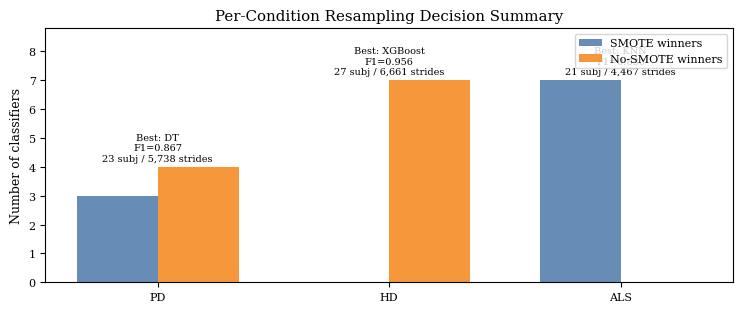

Saved: resampling_decision_summary.pdf / .png


In [45]:
summary_pdf = resampling_summary_df.to_pandas()
fig, ax = plt.subplots(figsize=(7.5, 3.2))

x = np.arange(len(summary_pdf))
width = 0.35
ax.bar(x - width/2, summary_pdf['SMOTE winners'], width, color='#4C78A8', alpha=0.85, label='SMOTE winners')
ax.bar(x + width/2, summary_pdf['No-SMOTE winners'], width, color='#F58518', alpha=0.85, label='No-SMOTE winners')

for idx, row in summary_pdf.iterrows():
    ax.text(
        idx,
        max(row['SMOTE winners'], row['No-SMOTE winners']) + 0.15,
        f"Best: {row['Best classifier']}\nF1={row['Best F1']:.3f}\n{row['Pool subjects']} subj / {row['Pool strides']:,} strides",
        ha='center',
        va='bottom',
        fontsize=7,
    )

ax.set_xticks(x)
ax.set_xticklabels(summary_pdf['Condition'])
ax.set_ylabel('Number of classifiers')
ax.set_ylim(0, 8.8)
ax.set_title('Per-Condition Resampling Decision Summary')
ax.legend(fontsize=8, loc='upper right')

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'resampling_decision_summary.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'resampling_decision_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: resampling_decision_summary.pdf / .png')


## Parkinson's Disease (PD) — Authoritative v2 baseline

In the authoritative v2 rerun, PD is best classified by **Decision Tree** (`F1 = 0.8668`). The resampling ablation is mixed rather than uniform: four PD classifiers prefer **no-SMOTE** and three prefer **SMOTE**. That makes PD the condition where model family and resampling choice interact most strongly.

For the transfer study, the key implication is that PD now has a materially stronger within-condition ceiling than the earlier flat-root notebook narrative assumed. The confusion matrix below therefore uses the stored **DT** predictions, not the earlier RF baseline.


In [46]:
# PD confusion matrix
cm_pd = confusion_matrix(y_true_pd, y_pred_pd)
cm_pd_norm = cm_pd.astype(float) / cm_pd.sum(axis=1, keepdims=True)

print(f"PD ({BEST_CLF_LABEL['pd']}) F1 macro: {f1_score(y_true_pd, y_pred_pd, average='macro'):.4f}")

class_labels = ['Control', 'Disease']


PD (DT) F1 macro: 0.8668


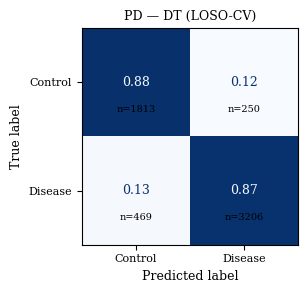

Saved: cm_pd_dt.pdf / .png


In [47]:
# PD confusion matrix — Matplotlib figure for paper (IEEE single-column)
fig, ax = plt.subplots(figsize=(3.5, 3.0))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pd_norm,
    display_labels=['Control', 'Disease'],
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

ax.set_title(f"PD — {BEST_CLF_LABEL['pd']} (LOSO-CV)", fontsize=9)
ax.set_xlabel('Predicted label', fontsize=9)
ax.set_ylabel('True label', fontsize=9)

for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.25, f'n={cm_pd[i, j]}', ha='center', va='center', fontsize=7, color='black')

fig.tight_layout()
fig.savefig(FIGURES_PDF / f"cm_pd_{BEST_CLF['pd']}.pdf", dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / f"cm_pd_{BEST_CLF['pd']}.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: cm_pd_{BEST_CLF['pd']}.pdf / .png")


## Huntington's Disease (HD) — Highest within-condition ceiling

HD is the cleanest within-condition problem in the authoritative v2 rerun. **XGBoost** is the best HD classifier (`F1 = 0.9562`), and all seven HD classifiers selected **no-SMOTE**, indicating that the source pool is already well-behaved enough that synthetic minority interpolation is not helpful.

That combination matters for Step 3: HD enters the transfer analysis with the strongest within-condition reference point and the most internally stable resampling decision profile.


In [48]:
# HD confusion matrix
cm_hd = confusion_matrix(y_true_hd, y_pred_hd)
cm_hd_norm = cm_hd.astype(float) / cm_hd.sum(axis=1, keepdims=True)

print(f"HD ({BEST_CLF_LABEL['hd']}) F1 macro: {f1_score(y_true_hd, y_pred_hd, average='macro'):.4f}")


HD (XGBoost) F1 macro: 0.9562


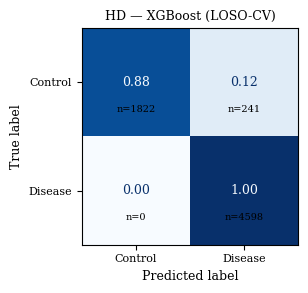

Saved: cm_hd_xgb.pdf / .png


In [49]:
# HD confusion matrix — Matplotlib figure for paper
fig, ax = plt.subplots(figsize=(3.5, 3.0))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hd_norm,
    display_labels=['Control', 'Disease'],
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

ax.set_title(f"HD — {BEST_CLF_LABEL['hd']} (LOSO-CV)", fontsize=9)
ax.set_xlabel('Predicted label', fontsize=9)
ax.set_ylabel('True label', fontsize=9)

for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.25, f'n={cm_hd[i, j]}', ha='center', va='center', fontsize=7, color='black')

fig.tight_layout()
fig.savefig(FIGURES_PDF / f"cm_hd_{BEST_CLF['hd']}.pdf", dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / f"cm_hd_{BEST_CLF['hd']}.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: cm_hd_{BEST_CLF['hd']}.pdf / .png")


## Amyotrophic Lateral Sclerosis (ALS) — KNN remains the best v2 baseline

ALS keeps the distinctive nearest-neighbour pattern in the authoritative v2 rerun: **KNN** is still best (`F1 = 0.8300`). Unlike PD and HD, ALS selects **SMOTE for all seven classifiers**, so the resampling decision is completely aligned across model families.

That consistency makes ALS especially useful for interpreting later transfer behaviour: when ALS-source transfer changes in Step 3, it is less likely to be a by-product of mixed source-side resampling decisions.


In [50]:
# ALS confusion matrix
cm_als = confusion_matrix(y_true_als, y_pred_als)
cm_als_norm = cm_als.astype(float) / cm_als.sum(axis=1, keepdims=True)

print(f"ALS ({BEST_CLF_LABEL['als']}) F1 macro: {f1_score(y_true_als, y_pred_als, average='macro'):.4f}")


ALS (KNN) F1 macro: 0.8300


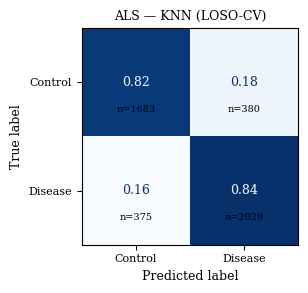

Saved: cm_als_knn.pdf / .png


In [51]:
# ALS confusion matrix — Matplotlib figure for paper
fig, ax = plt.subplots(figsize=(3.5, 3.0))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_als_norm,
    display_labels=['Control', 'Disease'],
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

ax.set_title(f"ALS — {BEST_CLF_LABEL['als']} (LOSO-CV)", fontsize=9)
ax.set_xlabel('Predicted label', fontsize=9)
ax.set_ylabel('True label', fontsize=9)

for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.25, f'n={cm_als[i, j]}', ha='center', va='center', fontsize=7, color='black')

fig.tight_layout()
fig.savefig(FIGURES_PDF / f"cm_als_{BEST_CLF['als']}.pdf", dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / f"cm_als_{BEST_CLF['als']}.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: cm_als_{BEST_CLF['als']}.pdf / .png")


## Cross-Condition Setup Takeaways

The authoritative Step 2 picture feeding Step 3 is now clear:

- **PD** has the most mixed resampling profile and the best v2 model is **DT**.
- **HD** has the strongest within-condition ceiling and chooses **no-SMOTE** for every classifier.
- **ALS** is the most internally consistent on resampling, with **SMOTE** selected for all seven classifiers and **KNN** remaining the best model.

These authoritative baselines are what the cross-condition transfer notebook should use for ΔF1 and for selecting the source-specific confusion-matrix classifier.


## Baseline Adequacy for Cross-Condition Transfer (Step 3)

The central question for Step 3 is whether the within-condition F1 scores provide a defensible ceiling for zero-shot transfer. Under the authoritative v2 rerun, the answer is yes.

The Step 2 rerun now supplies condition-specific ceilings that are strong enough to make transfer loss interpretable, while also exposing that the best classifier and best resampling choice differ by source condition. That heterogeneity is part of the scientific setup rather than a nuisance: Step 3 should compare each transferred classifier against its own within-condition v2 baseline, not against a single pooled source score.
